# Overview
This module is designed for students to perform data modeling for a voltaic cell under different conditions. Students will use Google Colab, Gemini, and Python programming language to read, interpret, and analyze provided data.

Written by Dr. Linlin Jensen

Some experimental data are taken from Brosmer, J. L. and Peters, D. G., *J. Chem. Educ.* 2012, 89, 6, 763 - 766, https://doi.org/10.1021/ed2004643

> **AI Use Disclaimer:** Google Gemini was used to improve clarity and organization of the activity’s written instructions.

### Learning Objectives
By the end of this recitation, you will be able to:
* Scientific Skills
  - **Data Interpretation:**: Interpret data to determine how changes in  concentrations influence cell potential.
  - **Graphical Representation:**: Graph and interpret how cell potential ($E_{cell}$) varies with concentrations and with logarithms of reaction quotients ($\text{log}⁡Q$) to identify trends.
  - **Mathematical Modeling:** Use the $E_{cell}$ vs. $\text{log}Q$ graph to determine the number of electrons transferred ($n$), the standard cell potential ($E^{o}_{cell}$), and the equilibrium constant ($K$), then evaluate whether these values match theoretical predictions.
* Cyberinfrastructure Skills
  - **Data Handling:** Import and load a CSV file into a Pandas DataFrame.
  - **Python Programming:**
    - Access and open a notebook in Google Colab
    - Identify and use the key components of the Google Colab interface (code cells, text cells, run button).
    - Read and understand a Python script with comments.
    - Run a Python script and interpret its output.
  - **Data Cleaning/Transformation:** Calculate $Q$ and $\text{log}Q$ using mathematical models.
  - **Data Visualization:** Generate scatter plots using Python libraries (e.g., Pandas, Matplotlib, NumPy/SciPy).
  - **Computational Analysis:** Perform a linear fit to find the slope and intercept.
  - **AI Literacy:** Formulate effective and specific prompts to get the most out of an AI assistant.

# Getting Started

## Download Files and Open Google Colab

1. Download the Colab notebook file (*.ipynb*) and the *.csv* file for your assigned cell from your recitation Canvas course. Once downloaded, these files will typically appear in your computer's Download folder.

2. Open your web browser and go to https://colab.research.google.com/.

3. Sign in with your Google account. If you don't have one, create a free account to continue.

## Open the Notebook in Colab:

4. On the Colab homepage, select File -> Open notebook.

5. Choose the **Upload** table and upload the downloaded *.ipynb* file.

## Upload the Experimental Data to Colab Worksheet.

6. In the left sidebar, click the folder icon to open the file browser.

7. Use the **Upload** button to add your .csv data file. Once uploaded, it will appear under the file list (below the *sample_data* subfolder).

## Gemini Prompt Tips:

For any step in the activities, if Gemini provides a list of tasks and asks you to choose between auto complete or step by step, select **Cancel**. Then copy and paste your prompt again, adding **Output only the full code block** at the end.

## Guidelines for Using AI Tools

Use AI tools only for tasks such as importing data, organizing or transforming it, and creating plots. For all other questions in the worksheet, rely on your own chemical understanding. **Do not ask AI tools to solve the conceptual or guiding questions for you.**

## Part 1: Read and Verify the Experimental Data

Prompt Gemini to import the .csv file for your assigned cell and display all data.

> After the cell finishes executing, compare the output data with the corresponding values in the input file. Answer the guiding questions in your recitation worksheet.


In [1]:
import pandas as pd

# Load the CSV file into a pandas DataFrame
df = pd.read_csv('/content/Cr_Co_Voltaic_Cell.csv')

# Display the DataFrame
display(df)

,Cr3+_Conc_Exp_A,Co2+_Conc_Exp_A,Voltage_Exp_A,Cr3+_Conc_Exp_B,Co2+_Conc_Exp_B,Voltage_Exp_B
0,0.1,0.001000,0.393690,0.001000,0.1,0.490624
1,0.1,0.001207,0.390195,0.001207,0.1,0.492773
2,0.1,0.001456,0.400381,0.001456,0.1,0.494898
3,0.1,0.001758,0.406106,0.001758,0.1,0.484261
4,0.1,0.002121,0.412940,0.002121,0.1,0.495794
5,0.1,0.002560,0.410248,0.002560,0.1,0.489085
6,0.1,0.003089,0.412500,0.003089,0.1,0.483914
7,0.1,0.003728,0.412779,0.003728,0.1,0.471562
8,0.1,0.004498,0.403064,0.004498,0.1,0.490331
9,0.1,0.005429,0.413497,0.005429,0.1,0.478868


# Part 2: Interpret and Visualize Imported Data

The imported dataset should include six columns. The first three columns correspond to Experiment A and the last three columns correspond to Experiment B.

Prompt Gemini plot E$_{cell}$ as a function of solution concentrations for Experiments A and B. Display the results as **side-by-side subplots**, using **different colors and marker styles** to clearly distinguish the experiments

> Right-click the images and paste them into your recitation worksheet. Answer the guiding questions.

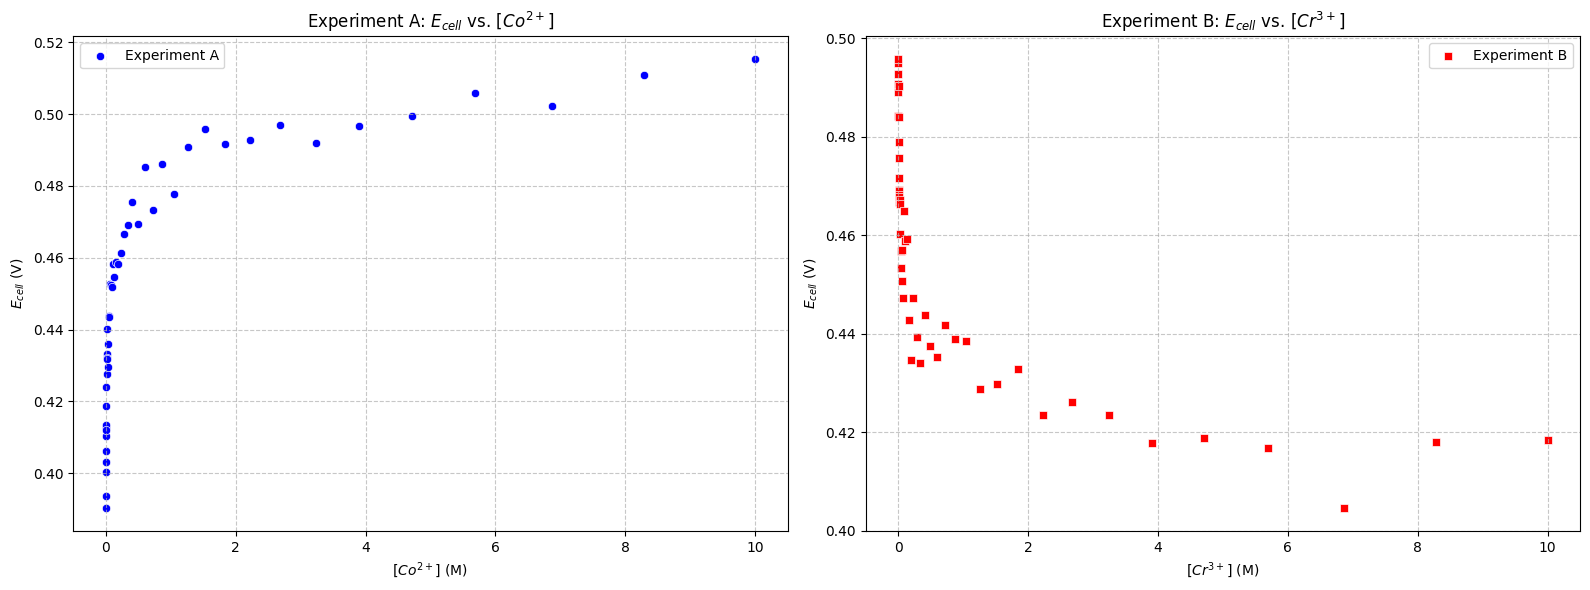

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots arranged side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot for Experiment A
sns.scatterplot(
    x='Co2+_Conc_Exp_A',
    y='Voltage_Exp_A',
    data=df,
    ax=axes[0],
    color='blue',
    marker='o',
    label='Experiment A'
)
axes[0].set_title('Experiment A: $E_{cell}$ vs. $[Co^{2+}]$')
axes[0].set_xlabel('$[Co^{2+}]$ (M)')
axes[0].set_ylabel('$E_{cell}$ (V)')
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend()

# Plot for Experiment B
sns.scatterplot(
    x='Cr3+_Conc_Exp_B',
    y='Voltage_Exp_B',
    data=df,
    ax=axes[1],
    color='red',
    marker='s',
    label='Experiment B'
)
axes[1].set_title('Experiment B: $E_{cell}$ vs. $[Cr^{3+}]$')
axes[1].set_xlabel('$[Cr^{3+}]$ (M)')
axes[1].set_ylabel('$E_{cell}$ (V)')
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend()

# Adjust layout to prevent overlapping titles and labels
plt.tight_layout()
plt.show()

In [3]:
import numpy as np

# Calculate Q and log Q for Experiment A
df['Q_Exp_A'] = (df['Cr3+_Conc_Exp_A']**2) / (df['Co2+_Conc_Exp_A']**3)
df['logQ_Exp_A'] = np.log10(df['Q_Exp_A'])

# Calculate Q and log Q for Experiment B
df['Q_Exp_B'] = (df['Cr3+_Conc_Exp_B']**2) / (df['Co2+_Conc_Exp_B']**3)
df['logQ_Exp_B'] = np.log10(df['Q_Exp_B'])

# Display the first five rows with the new columns
display(df.head())

,Cr3+_Conc_Exp_A,Co2+_Conc_Exp_A,Voltage_Exp_A,Cr3+_Conc_Exp_B,Co2+_Conc_Exp_B,Voltage_Exp_B,Q_Exp_A,logQ_Exp_A,Q_Exp_B,logQ_Exp_B
0,0.1,0.001000,0.393690,0.001000,0.1,0.490624,1.000000e+07,7.000000,0.001000,-3.000000
1,0.1,0.001207,0.390195,0.001207,0.1,0.492773,5.689861e+06,6.755102,0.001456,-2.836734
2,0.1,0.001456,0.400381,0.001456,0.1,0.494898,3.237461e+06,6.510205,0.002121,-2.673470
3,0.1,0.001758,0.406106,0.001758,0.1,0.484261,1.842069e+06,6.265306,0.003089,-2.510204
4,0.1,0.002121,0.412940,0.002121,0.1,0.495794,1.048113e+06,6.020408,0.004498,-2.346939


# Part 3: Transform Data and Visualize Transformed Data

1. Prompt Gemini to calculate $Q$ and log $Q$ for each concentration set in each experiment and display the first five rows of results.
>Verify that the expression for the reaction quotient ($Q$) in the code is implemented correctly. Answer the guiding questions in your recitation worksheet.

2. Prompt Gemini to plot $E_{cell}$ as a function of $Q$ and log $⁡Q$ for each experiment. Present the results in a **2x2 grid of subplots, using distinct colors and marker styles** to clearly differentiate between the experiments and the plotted variables.
> Right-click the images and paste them into your recitation worksheet. Answer the guiding questions.

3. Prompt Gemini to perform a **linear regression** analysis for each $E_{cell}$ vs. log $Q$ subplot. Overlay the best-fit line on the corresponding plot and display the associated fit parameters (slope and intercept). Present **only the updated plots** showing both the data and the regression results.
> Right-click the images and paste them into your recitation worksheet. Answer the guiding questions.


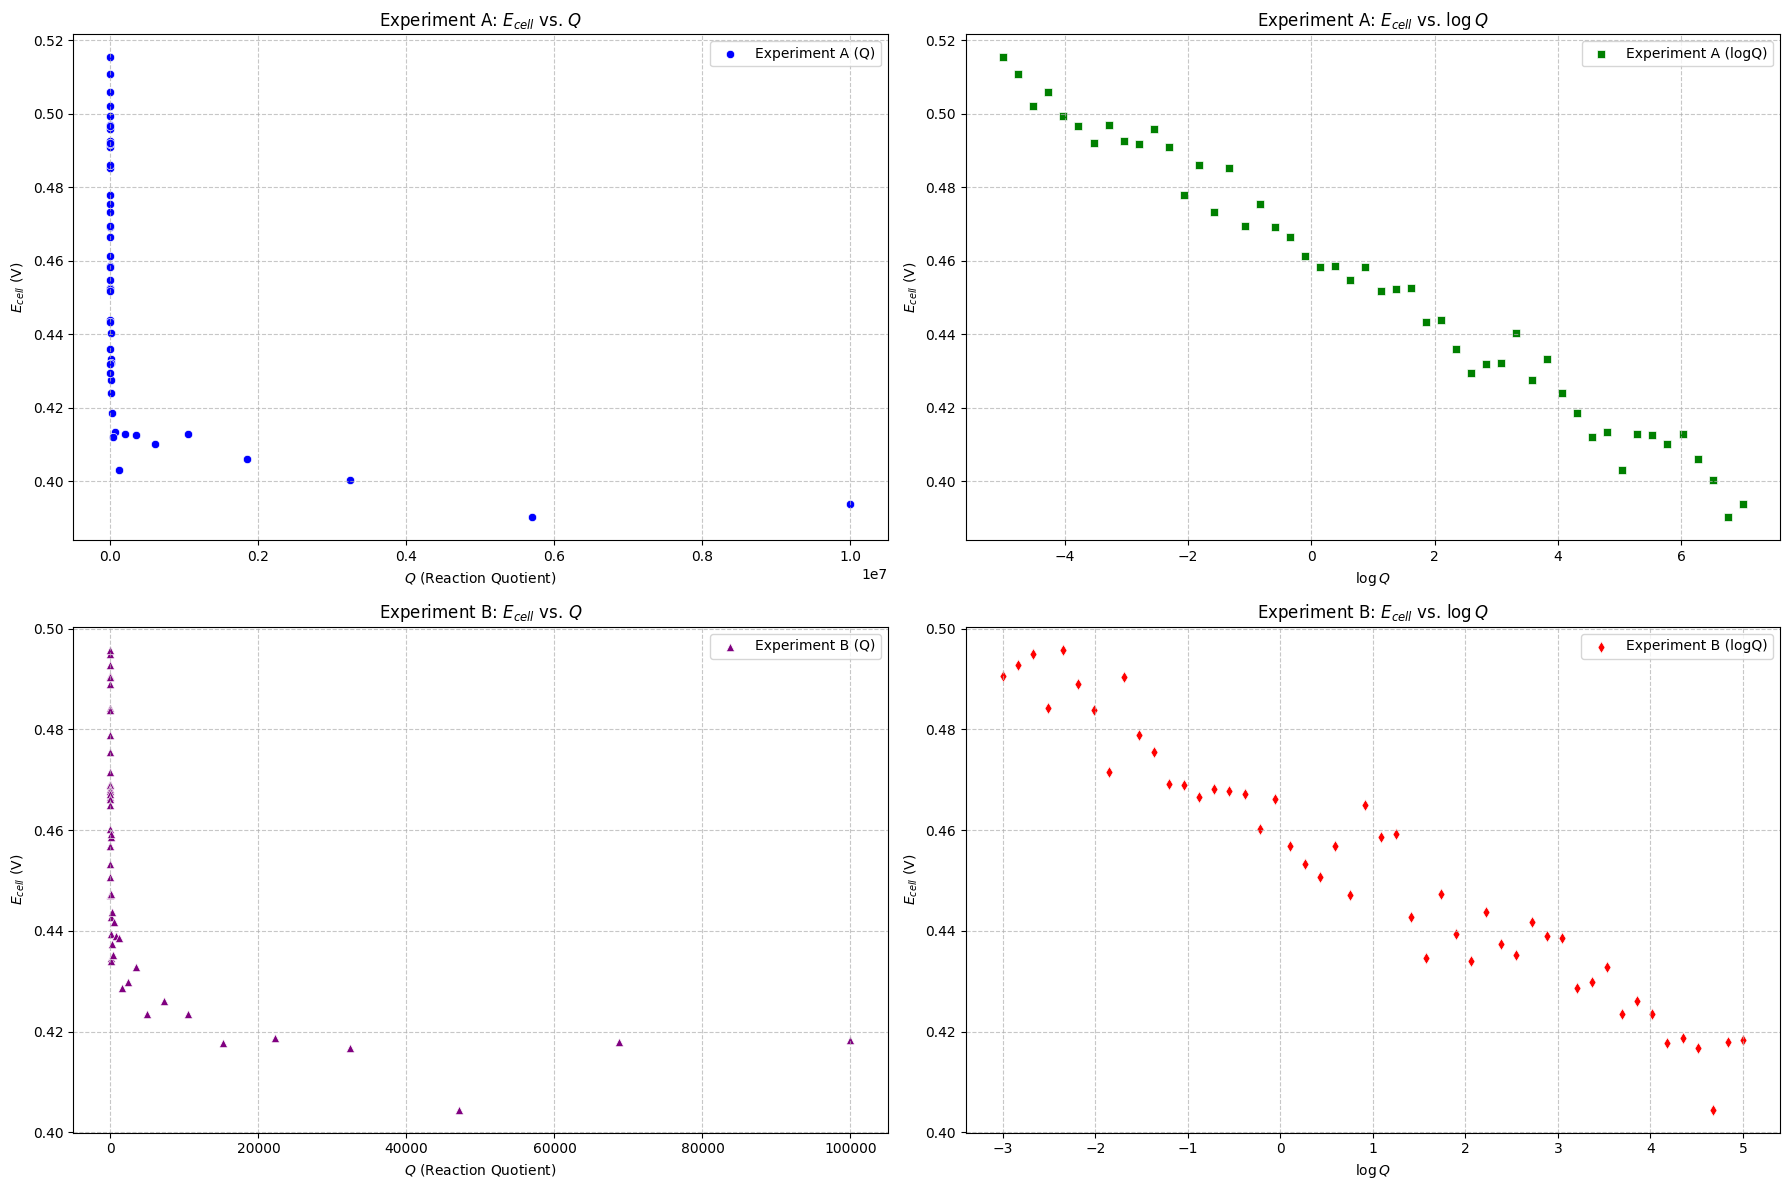

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot for Experiment A: E_cell vs Q
sns.scatterplot(
    x='Q_Exp_A',
    y='Voltage_Exp_A',
    data=df,
    ax=axes[0, 0],
    color='blue',
    marker='o',
    label='Experiment A (Q)'
)
axes[0, 0].set_title('Experiment A: $E_{cell}$ vs. $Q$')
axes[0, 0].set_xlabel('$Q$ (Reaction Quotient)')
axes[0, 0].set_ylabel('$E_{cell}$ (V)')
axes[0, 0].grid(True, linestyle='--', alpha=0.7)
axes[0, 0].legend()

# Plot for Experiment A: E_cell vs logQ
sns.scatterplot(
    x='logQ_Exp_A',
    y='Voltage_Exp_A',
    data=df,
    ax=axes[0, 1],
    color='green',
    marker='s',
    label='Experiment A (logQ)'
)
axes[0, 1].set_title('Experiment A: $E_{cell}$ vs. $\\log Q$')
axes[0, 1].set_xlabel('$\\log Q$')
axes[0, 1].set_ylabel('$E_{cell}$ (V)')
axes[0, 1].grid(True, linestyle='--', alpha=0.7)
axes[0, 1].legend()

# Plot for Experiment B: E_cell vs Q
sns.scatterplot(
    x='Q_Exp_B',
    y='Voltage_Exp_B',
    data=df,
    ax=axes[1, 0],
    color='purple',
    marker='^',
    label='Experiment B (Q)'
)
axes[1, 0].set_title('Experiment B: $E_{cell}$ vs. $Q$')
axes[1, 0].set_xlabel('$Q$ (Reaction Quotient)')
axes[1, 0].set_ylabel('$E_{cell}$ (V)')
axes[1, 0].grid(True, linestyle='--', alpha=0.7)
axes[1, 0].legend()

# Plot for Experiment B: E_cell vs logQ
sns.scatterplot(
    x='logQ_Exp_B',
    y='Voltage_Exp_B',
    data=df,
    ax=axes[1, 1],
    color='red',
    marker='d',
    label='Experiment B (logQ)'
)
axes[1, 1].set_title('Experiment B: $E_{cell}$ vs. $\\log Q$')
axes[1, 1].set_xlabel('$\\log Q$')
axes[1, 1].set_ylabel('$E_{cell}$ (V)')
axes[1, 1].grid(True, linestyle='--', alpha=0.7)
axes[1, 1].legend()

# Adjust layout to prevent overlapping titles and labels
plt.tight_layout()
plt.show()

Experiment A Linear Regression: Slope = -0.0098, Intercept = 0.4632
Experiment A R-squared = 0.9827
Experiment B Linear Regression: Slope = -0.0100, Intercept = 0.4624
Experiment B R-squared = 0.9470


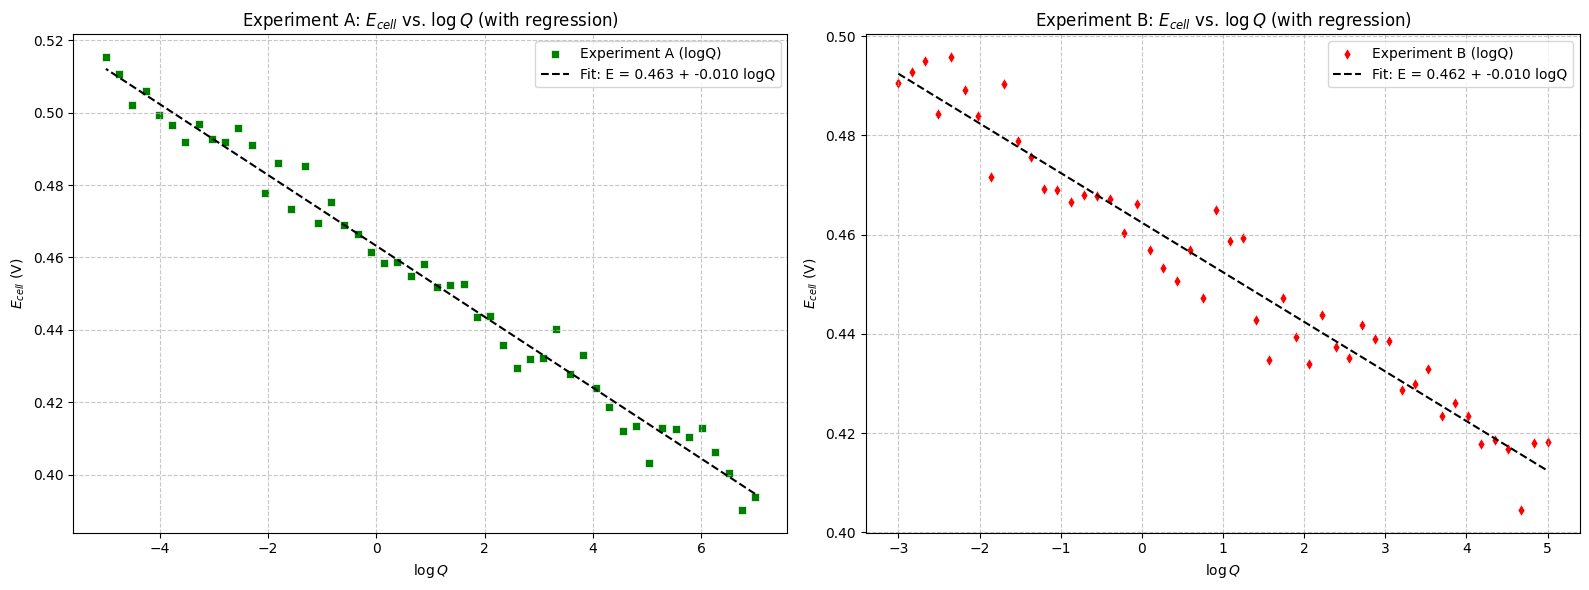

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
import numpy as np

# Create a figure with two subplots arranged side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Experiment A: E_cell vs logQ with linear regression ---
sns.scatterplot(
    x='logQ_Exp_A',
    y='Voltage_Exp_A',
    data=df,
    ax=axes[0],
    color='green',
    marker='s',
    label='Experiment A (logQ)'
)
# Perform linear regression for Experiment A
logQ_A = df['logQ_Exp_A']
voltage_A = df['Voltage_Exp_A']
slope_A, intercept_A, r_value_A, p_value_A, std_err_A = linregress(logQ_A, voltage_A)
axes[0].plot(logQ_A, intercept_A + slope_A * logQ_A, color='black', linestyle='--', label=f'Fit: E = {intercept_A:.3f} + {slope_A:.3f} logQ')
axes[0].set_title('Experiment A: $E_{cell}$ vs. $\\log Q$ (with regression)')
axes[0].set_xlabel('$\\log Q$')
axes[0].set_ylabel('$E_{cell}$ (V)')
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend()
print(f"Experiment A Linear Regression: Slope = {slope_A:.4f}, Intercept = {intercept_A:.4f}")
print(f"Experiment A R-squared = {r_value_A**2:.4f}")

# --- Experiment B: E_cell vs logQ with linear regression ---
sns.scatterplot(
    x='logQ_Exp_B',
    y='Voltage_Exp_B',
    data=df,
    ax=axes[1],
    color='red',
    marker='d',
    label='Experiment B (logQ)'
)
# Perform linear regression for Experiment B
logQ_B = df['logQ_Exp_B']
voltage_B = df['Voltage_Exp_B']
slope_B, intercept_B, r_value_B, p_value_B, std_err_B = linregress(logQ_B, voltage_B)
axes[1].plot(logQ_B, intercept_B + slope_B * logQ_B, color='black', linestyle='--', label=f'Fit: E = {intercept_B:.3f} + {slope_B:.3f} logQ')
axes[1].set_title('Experiment B: $E_{cell}$ vs. $\\log Q$ (with regression)')
axes[1].set_xlabel('$\\log Q$')
axes[1].set_ylabel('$E_{cell}$ (V)')
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend()
print(f"Experiment B Linear Regression: Slope = {slope_B:.4f}, Intercept = {intercept_B:.4f}")
print(f"Experiment B R-squared = {r_value_B**2:.4f}")

# Adjust layout to prevent overlapping titles and labels
plt.tight_layout()
plt.show()

# Reflection:

**Complete the reflection questions in the recitation worksheet.**

# Final Notes about Grading:
In addition to completing the guiding questions, your TA will check that you followed the activity instructions. Submit shareable links to your Colab Notebook as part of your participation. **To share your Colab notebook:**

1. Rename your copy: Change the filename to include YOUR name (the student's name), not your instructor's name.

2. Share your notebook: Set the sharing permissions so that anyone with the link can view (or as your instructor specifies).

3.	Copy and paste your sharable links into the Exit Form so your instructor and TA can access your work.